In [1]:
import pandas as pd
import seaborn as sns

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
titanic = pd.read_csv('train.csv')

In [5]:
flights = sns.load_dataset('flights')

In [6]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [7]:
iris = sns.load_dataset('iris')

In [8]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## 1. Scatterplot (Numerical - Numerical)


<Axes: xlabel='total_bill', ylabel='tip'>

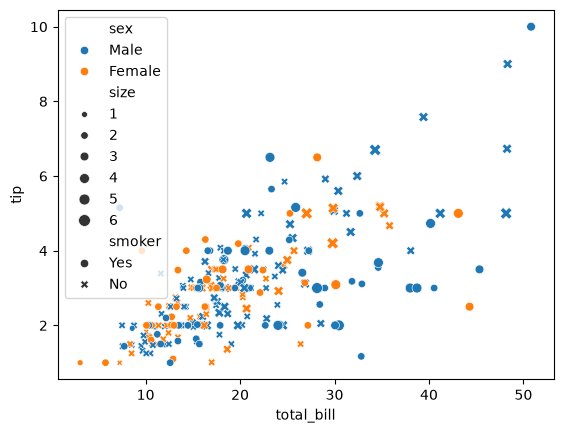

In [9]:
sns.scatterplot(
    data=tips, 
    x='total_bill', 
    y='tip', 
    hue='sex', 
    style='smoker', 
    size='size'
)

## 2. Bar Plot (Numerical - Categorical)

In [10]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Age'>

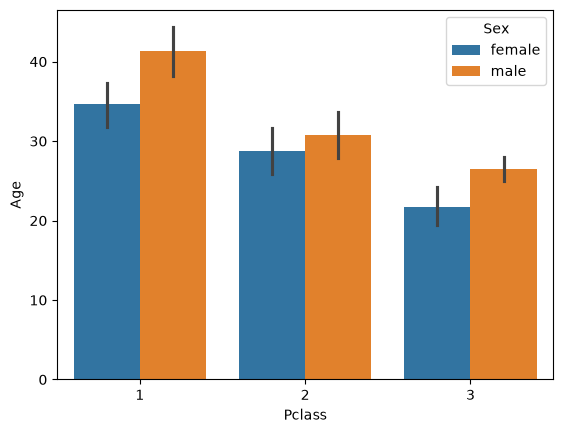

In [11]:
sns.barplot(data=titanic,x='Pclass',y='Age',hue='Sex')

## 3. Box Plot (Numerical - Categorical)

In [13]:
sns.boxplot(titanic['Sex'],titanic['Age'],hue=titanic['Survived']) #old way

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Axes: xlabel='Sex', ylabel='Age'>

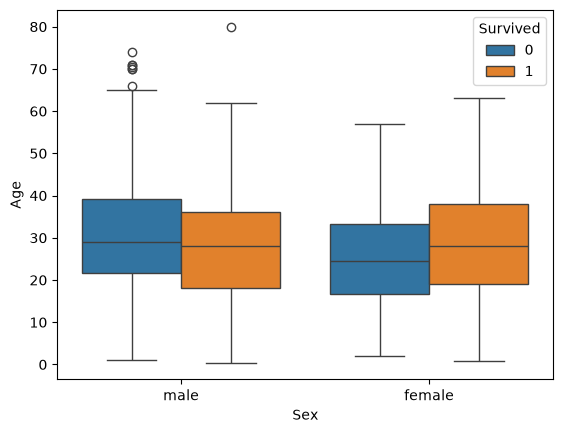

In [16]:
sns.boxplot(data=titanic,x='Sex',y='Age',hue='Survived') #new method

## 4. Distplot (Numerical - Categorical)

<Axes: xlabel='Age', ylabel='Density'>

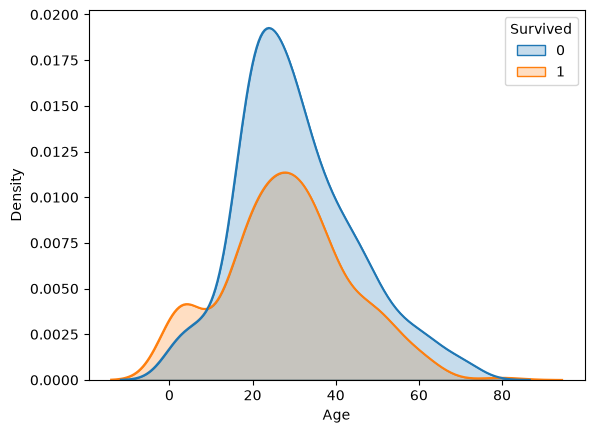

In [17]:
sns.kdeplot(data=titanic, x='Age', hue='Survived')
sns.kdeplot(data=titanic, x='Age', hue='Survived', fill=True)

## 5. HeatMap (Categorical - Categorical)

In [18]:
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


<Axes: xlabel='Survived', ylabel='Pclass'>

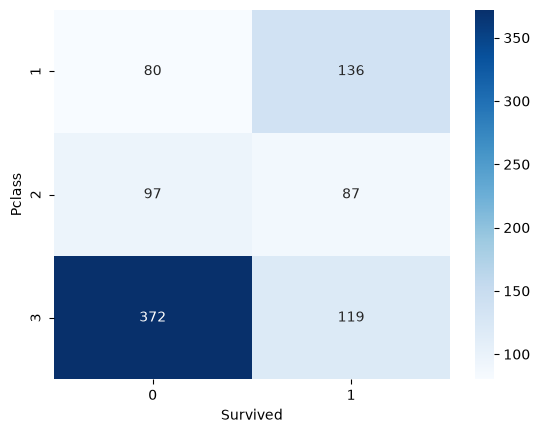

In [19]:
# The enhanced, professional way to write it
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic['Survived']), annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='Survived', ylabel='Pclass'>

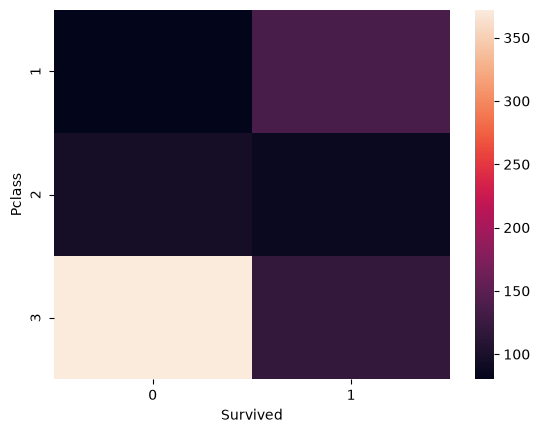

In [21]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived'])) #traditional

In [23]:
#(titanic.groupby('Embarked').mean()['Survived']*100)
# Select the column first, THEN calculate the mean
(titanic.groupby('Embarked')['Survived'].mean() * 100)

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

## 6. ClusterMap (Categorical - Categorical)

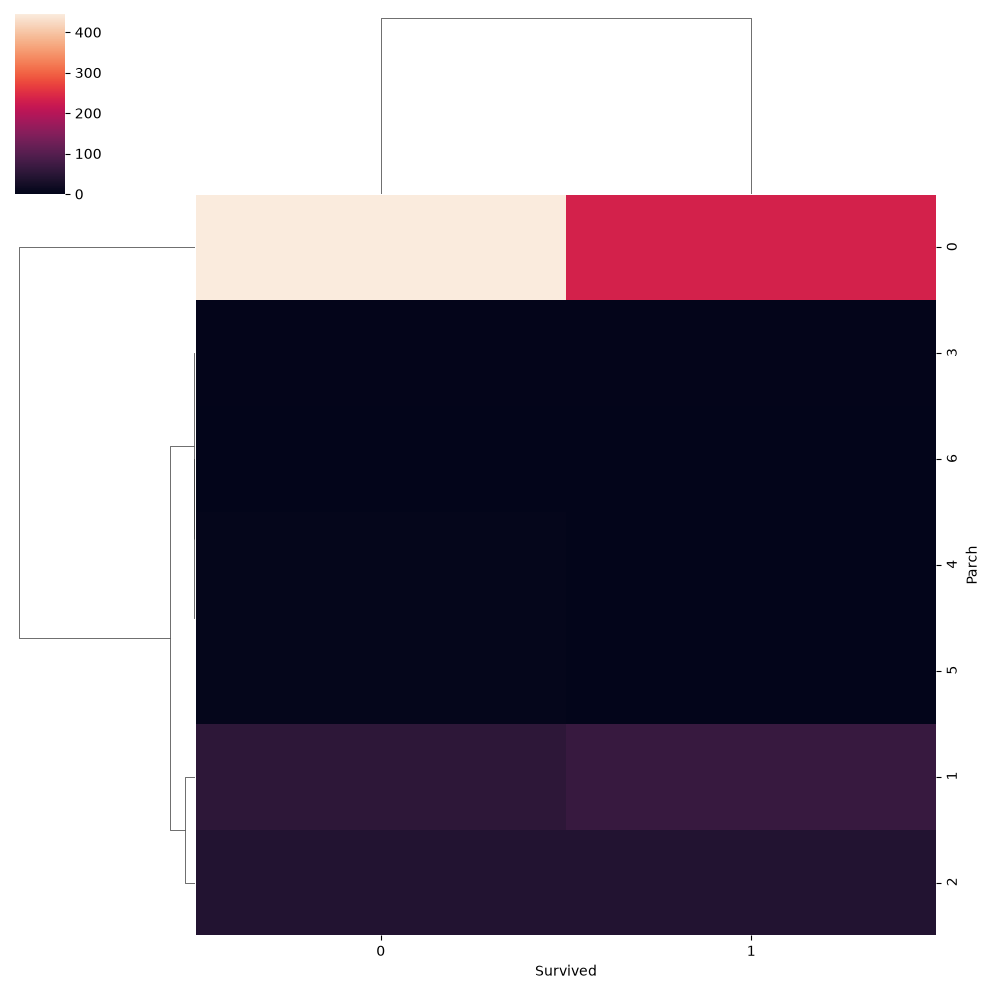

In [24]:
sns.clustermap(pd.crosstab(titanic['Parch'],titanic['Survived']))

## 7. Pairplot

In [25]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


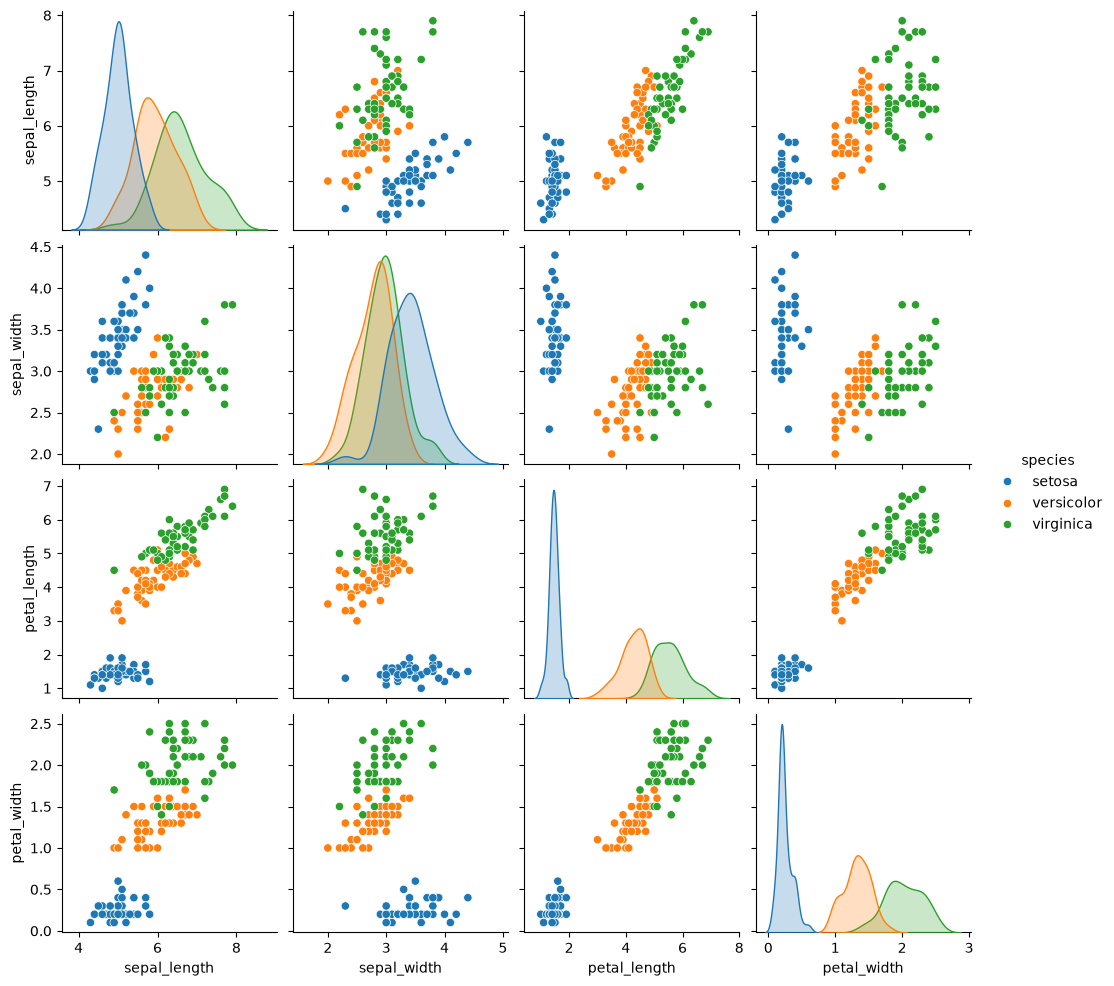

In [26]:
sns.pairplot(iris,hue='species')

## 8. Lineplot (Numerical - Numerical)

In [27]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [30]:
#new = flights.groupby('year').sum().reset_index()
# The modern, bulletproof way
new = flights.groupby('year')['passengers'].sum().reset_index()

<Axes: xlabel='year', ylabel='passengers'>

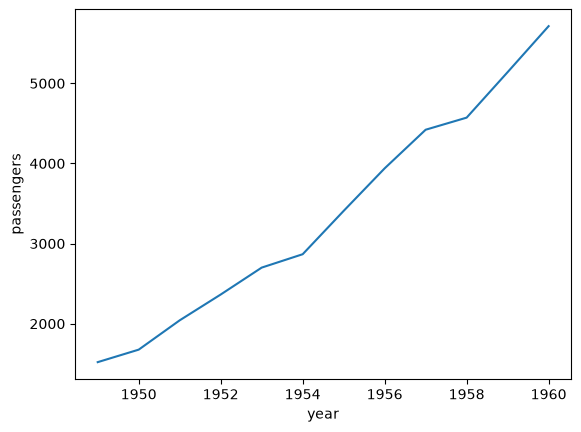

In [32]:
#sns.lineplot(new['year'],new['passengers'])
sns.lineplot(data=new, x='year', y='passengers')

<Axes: xlabel='year', ylabel='passengers'>

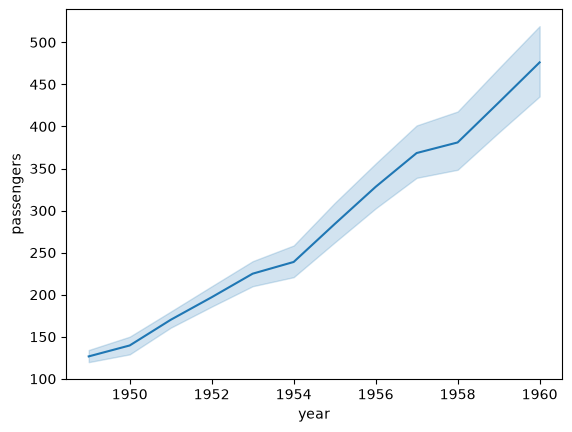

In [33]:
sns.lineplot(data=flights, x='year', y='passengers')

C:\Users\vanda\AppData\Local\Temp\ipykernel_19140\2587072455.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flight_pivot = flights.pivot_table(index='month', columns='year', values='passengers')


<Axes: xlabel='year', ylabel='month'>

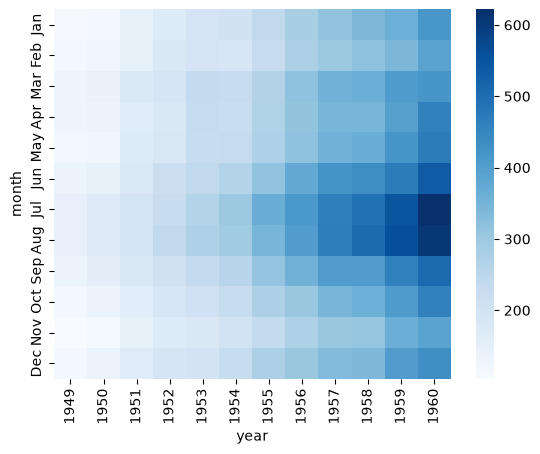

In [34]:
# 1. Pivot the data into a grid
flight_pivot = flights.pivot_table(index='month', columns='year', values='passengers')

# 2. Plot it with a heatmap
sns.heatmap(flight_pivot, cmap='Blues')

In [35]:
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


C:\Users\vanda\AppData\Local\Temp\ipykernel_19140\1868718285.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))


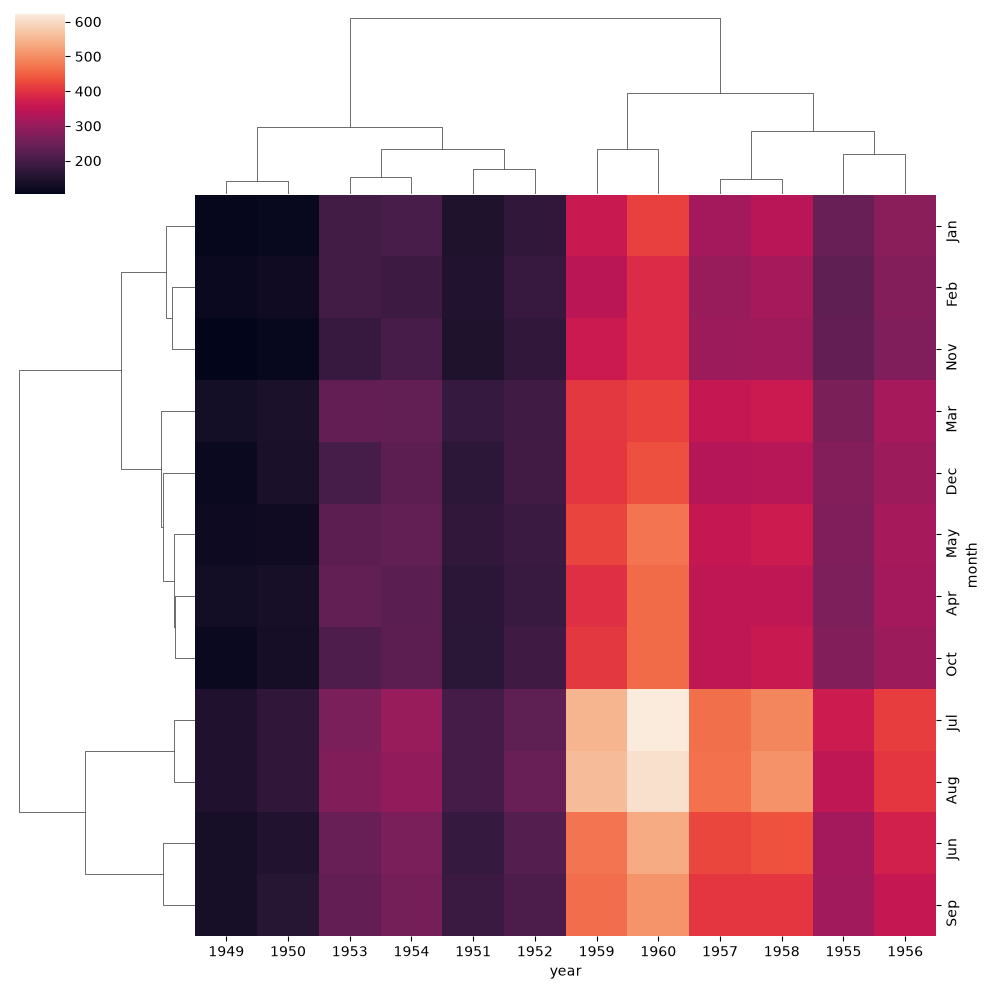

In [36]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))

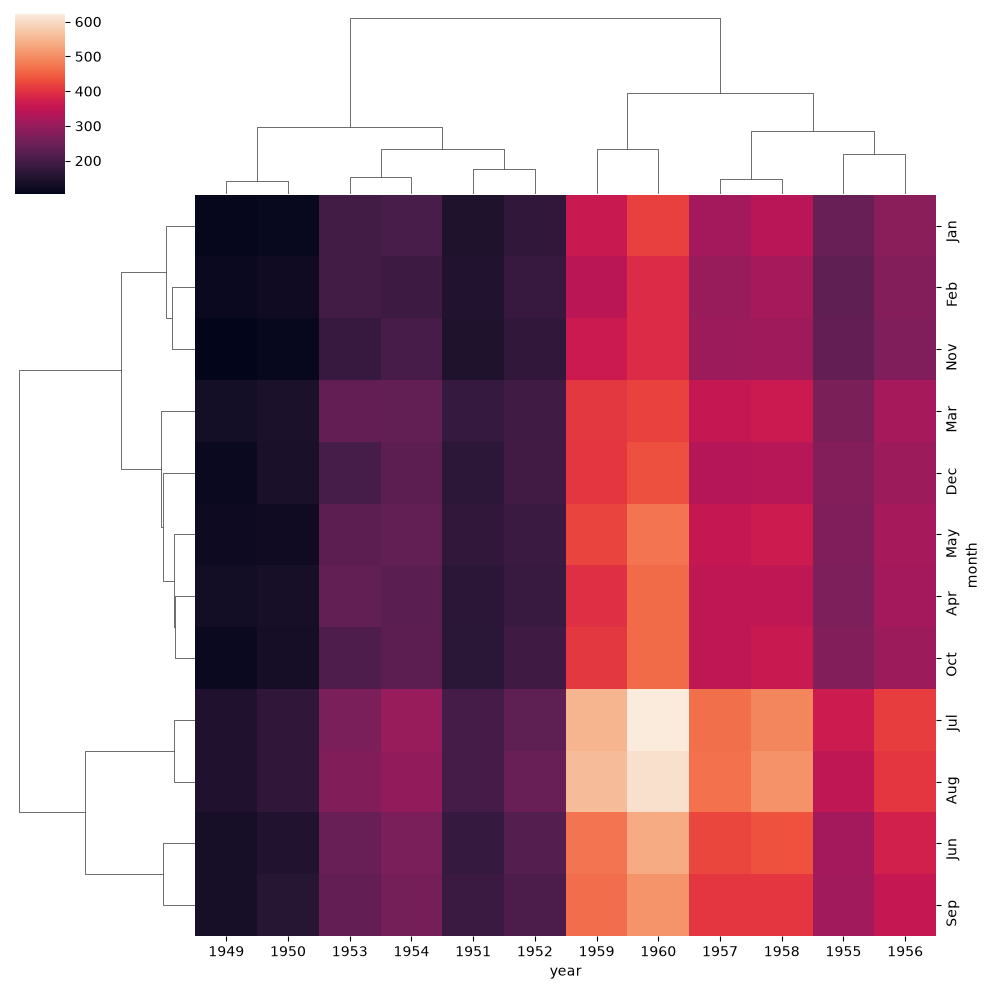

In [37]:
flight_matrix = flights.pivot_table(
    values='passengers', 
    index='month', 
    columns='year', 
    observed=False  # This completely silences the warning
)

sns.clustermap(flight_matrix)